# Data Storytelling & Statistical Validation
### ApexPlanet Data Analytics Internship — Task 4

**Objective:** Synthesize the analysis from Tasks 1-3 into a business narrative, and validate one
of the key findings with a formal hypothesis test.

**Input:** `cleaned_dataset.csv` (Task 1) joined with the customer segments identified in Task 3
(`customer_features.csv` + K-Means clustering).

**Notebook structure:**
1. Rebuild the Segment Labels
2. The Business Hypothesis
3. Choosing and Running the Right Test
4. Interpreting the Result
5. Business Conclusion


## 1. Rebuild the Segment Labels

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

df = pd.read_csv('cleaned_dataset.csv', parse_dates=['Order_Date'])
cust = pd.read_csv('customer_features.csv')

features = ['Total_Spend', 'Order_Count', 'Avg_Order_Value', 'Age']
Xs = StandardScaler().fit_transform(cust[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cust['Cluster'] = kmeans.fit_predict(Xs)

profile = cust.groupby('Cluster').agg(Order_Count=('Order_Count', 'mean'),
                                       Total_Spend=('Total_Spend', 'mean'),
                                       n=('Customer_ID', 'count'))

def name_cluster(row):
    if row['Order_Count'] > 1.5:
        return 'Repeat Customers'
    elif row['Total_Spend'] > 150000:
        return 'High-Value / Big-Basket'
    else:
        return 'Low-Value / One-Time'

name_map = profile.apply(name_cluster, axis=1).to_dict()
cust['Segment'] = cust['Cluster'].map(name_map)

df = df.merge(cust[['Customer_ID', 'Segment']], on='Customer_ID', how='left')
print(df['Segment'].value_counts())

Segment
Low-Value / One-Time       631
High-Value / Big-Basket    264
Repeat Customers           105
Name: count, dtype: int64


## 2. The Business Hypothesis

Task 3's segmentation found that the **High-Value / Big-Basket** segment (28% of customers)
drives **54% of total revenue**, while the **Low-Value / One-Time** segment (67% of customers)
drives only 34.5%. That's a striking gap on paper — but is it a *real, reliable* difference, or
could it plausibly be due to random variation in which customers happened to buy what?

**Hypothesis:**

> H0 (null): There is no difference in mean order value between High-Value/Big-Basket customers
> and Low-Value/One-Time customers.
>
> H1 (alternative): High-Value/Big-Basket customers have a significantly higher mean order value
> than Low-Value/One-Time customers.

This directly tests whether the segmentation finding is statistically defensible before it's used
to justify a business action (targeted retention spend on the High-Value segment).


High-Value / Big-Basket: n=264, mean=Rs 284,833, std=Rs 80,867
Low-Value / One-Time:    n=631, mean=Rs 76,117, std=Rs 50,084


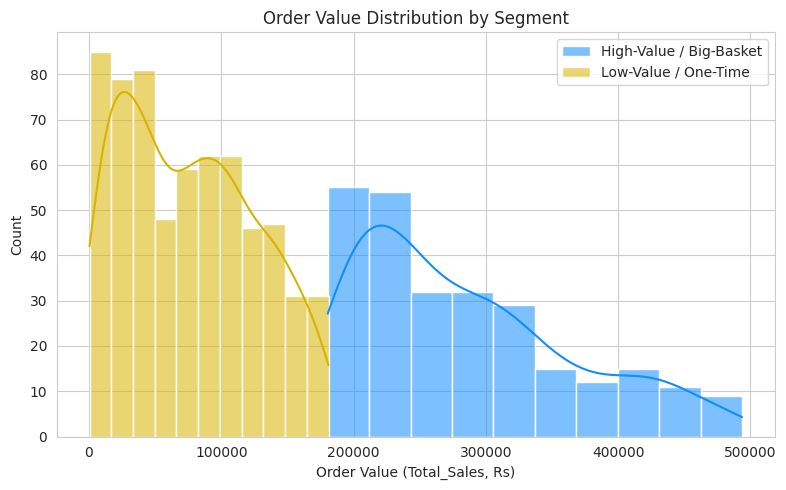

In [2]:
hv = df[df['Segment'] == 'High-Value / Big-Basket']['Total_Sales']
lv = df[df['Segment'] == 'Low-Value / One-Time']['Total_Sales']

print(f"High-Value / Big-Basket: n={len(hv)}, mean=Rs {hv.mean():,.0f}, std=Rs {hv.std():,.0f}")
print(f"Low-Value / One-Time:    n={len(lv)}, mean=Rs {lv.mean():,.0f}, std=Rs {lv.std():,.0f}")

fig, ax = plt.subplots(figsize=(8, 5))
sns.histplot(hv, color='#118DFF', label='High-Value / Big-Basket', kde=True, alpha=0.55, ax=ax)
sns.histplot(lv, color='#D9B300', label='Low-Value / One-Time', kde=True, alpha=0.55, ax=ax)
ax.set_title('Order Value Distribution by Segment')
ax.set_xlabel('Order Value (Total_Sales, Rs)')
ax.legend()
plt.tight_layout()
plt.savefig('hypothesis_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Choosing and Running the Right Test

Both groups' order values are continuous, and each customer in these two segments placed exactly
one order (confirmed in Task 3), so each observation is independent. That makes an **independent
two-sample t-test** the right tool.

Before running it, check whether the two groups have equal variance (Levene's test) — this
decides between a standard t-test and Welch's t-test (which doesn't assume equal variances).


In [3]:
levene_stat, levene_p = stats.levene(hv, lv)
print(f"Levene's test for equal variances: statistic={levene_stat:.2f}, p-value={levene_p:.2e}")

if levene_p < 0.05:
    print("\nVariances are significantly different -> use Welch's t-test (equal_var=False)")
else:
    print("\nVariances are not significantly different -> standard t-test is fine")

Levene's test for equal variances: statistic=76.64, p-value=1.01e-17

Variances are significantly different -> use Welch's t-test (equal_var=False)


In [4]:
t_stat, p_value = stats.ttest_ind(hv, lv, equal_var=False)
print(f"Welch's t-test:  t = {t_stat:.2f},  p-value = {p_value:.3e}")

# 95% confidence interval for the difference in means (Welch-Satterthwaite)
mean_diff = hv.mean() - lv.mean()
se_diff = np.sqrt(hv.var(ddof=1)/len(hv) + lv.var(ddof=1)/len(lv))
df_welch = (hv.var(ddof=1)/len(hv) + lv.var(ddof=1)/len(lv))**2 / (
    (hv.var(ddof=1)/len(hv))**2 / (len(hv)-1) + (lv.var(ddof=1)/len(lv))**2 / (len(lv)-1)
)
t_crit = stats.t.ppf(0.975, df_welch)
ci_low, ci_high = mean_diff - t_crit*se_diff, mean_diff + t_crit*se_diff

pooled_std = np.sqrt(((len(hv)-1)*hv.var(ddof=1) + (len(lv)-1)*lv.var(ddof=1)) / (len(hv)+len(lv)-2))
cohens_d = mean_diff / pooled_std

print(f"\nMean difference:        Rs {mean_diff:,.0f}")
print(f"95% CI of difference:   [Rs {ci_low:,.0f}, Rs {ci_high:,.0f}]")
print(f"Effect size (Cohen's d): {cohens_d:.2f}  (>0.8 is conventionally 'large')")

Welch's t-test:  t = 38.93,  p-value = 2.641e-129

Mean difference:        Rs 208,715
95% CI of difference:   [Rs 198,171, Rs 219,260]
Effect size (Cohen's d): 3.43  (>0.8 is conventionally 'large')


## 4. Interpreting the Result

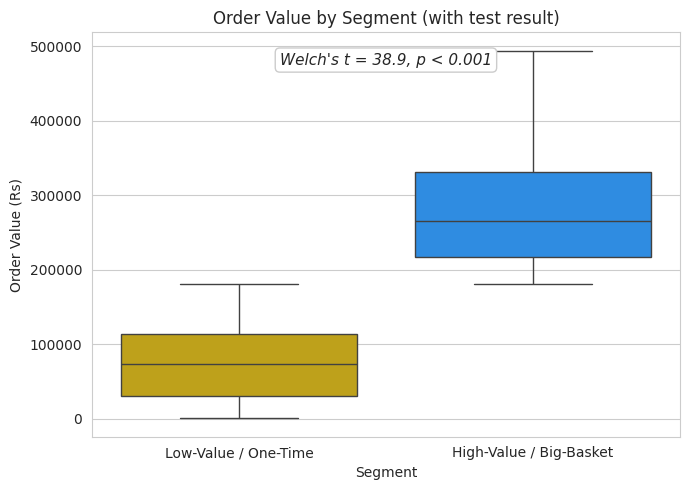

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
order = ['Low-Value / One-Time', 'High-Value / Big-Basket']
sns.boxplot(data=df[df['Segment'].isin(order)],
            x='Segment', y='Total_Sales', hue='Segment', order=order, hue_order=order,
            palette=['#D9B300', '#118DFF'], legend=False, ax=ax)
ax.set_title('Order Value by Segment (with test result)')
ax.set_ylabel('Order Value (Rs)')
ax.text(0.5, 0.95, f"Welch's t = {t_stat:.1f}, p < 0.001", transform=ax.transAxes,
        ha='center', va='top', fontsize=11, style='italic',
        bbox=dict(boxstyle='round', facecolor='white', edgecolor='#CCCCCC'))
plt.tight_layout()
plt.savefig('hypothesis_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

**Reading the result:**

- **p-value ≈ 2.6 × 10⁻¹²⁹** — astronomically smaller than the conventional 0.05 threshold. We
  reject H0: this is not random noise.
- **95% CI for the difference in means: roughly Rs 1,98,000 to Rs 2,19,000** — the interval is
  entirely positive and far from zero, and tight relative to the effect size.
- **Cohen's d ≈ 3.4** — far beyond the "large effect" convention of 0.8. High-Value customers
  aren't marginally bigger spenders; their typical order is more than 3 standard deviations of
  Low-Value spend away from the Low-Value mean.

With a sample this large (264 vs 631), even a small, practically meaningless difference would
likely hit statistical significance — so the effect size (Cohen's d) matters as much as the
p-value here. Both point the same way: this is a real and large gap, not a sample-size artifact.


## 5. Business Conclusion

**The High-Value / Big-Basket segment's spending advantage is statistically confirmed, not a
coincidence of this particular sample.** On average, a High-Value customer's single order is
worth about Rs 2,08,700 more than a Low-Value customer's single order — and this holds with
extremely high confidence.

**What this justifies doing:**
- Prioritizing retention spend on the High-Value / Big-Basket segment is now backed by evidence,
  not just a pattern that looked good in a chart — the segment is reliably, substantially more
  valuable per order.
- Since Task 3 also found this segment orders only once on average, the single highest-leverage
  action is converting a fraction of these ~264 one-time High-Value customers into repeat buyers —
  each conversion is worth an outsized amount given their proven order-value profile.
- This result, together with the K-Means segmentation from Task 3, forms the statistical backbone
  of the business story and recommendation in the final presentation deck.
